In [1]:
import json
import pickle

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/engineered_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (10151, 6)


,location,total_sqft,bath,price,bhk,price_per_sqft
0,Devarachikkanahalli,1250.0,2.0,44.0,3,3520.000000
1,Devarachikkanahalli,1250.0,2.0,40.0,2,3200.000000
2,Devarachikkanahalli,1200.0,2.0,83.0,2,6916.666667
3,Devarachikkanahalli,1170.0,2.0,40.0,2,3418.803419
4,Devarachikkanahalli,1425.0,2.0,65.0,3,4561.403509


In [2]:
dummies = pd.get_dummies(df["location"])
df = pd.concat([df, dummies], axis=1)
df = df.drop("location", axis=1)
print("Shape after encoding:", df.shape)

Shape after encoding: (10151, 246)


In [3]:
df = df.drop("price_per_sqft", axis=1)
print(df.columns.tolist())

['total_sqft', 'bath', 'price', 'bhk', ' Devarachikkanahalli', '1st Block Jayanagar', '1st Phase JP Nagar', '2nd Phase Judicial Layout', '2nd Stage Nagarbhavi', '5th Block Hbr Layout', '5th Phase JP Nagar', '6th Phase JP Nagar', '7th Phase JP Nagar', '8th Phase JP Nagar', '9th Phase JP Nagar', 'AECS Layout', 'Abbigere', 'Akshaya Nagar', 'Ambalipura', 'Ambedkar Nagar', 'Amruthahalli', 'Anandapura', 'Ananth Nagar', 'Anekal', 'Anjanapura', 'Ardendale', 'Arekere', 'Attibele', 'BEML Layout', 'BTM 2nd Stage', 'BTM Layout', 'Babusapalaya', 'Badavala Nagar', 'Balagere', 'Banashankari', 'Banashankari Stage II', 'Banashankari Stage III', 'Banashankari Stage V', 'Banashankari Stage VI', 'Banaswadi', 'Banjara Layout', 'Bannerghatta', 'Bannerghatta Road', 'Basavangudi', 'Basaveshwara Nagar', 'Battarahalli', 'Begur', 'Begur Road', 'Bellandur', 'Benson Town', 'Bharathi Nagar', 'Bhoganhalli', 'Billekahalli', 'Binny Pete', 'Bisuvanahalli', 'Bommanahalli', 'Bommasandra', 'Bommasandra Industrial Area', '

In [4]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (8120, 244) Test: (2031, 244)


In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
lr_score = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression R²:", round(lr_score, 4))
print("Linear Regression MAE:", round(lr_mae, 4))

Linear Regression R²: 0.7554
Linear Regression MAE: 19.5285


In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_score = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest R²:", round(rf_score, 4))
print("Random Forest MAE:", round(rf_mae, 4))

Random Forest R²: 0.6672
Random Forest MAE: 18.3867


In [7]:
if rf_score >= lr_score:
    best_model = rf
    best_name = "Random Forest"
    best_score = rf_score
else:
    best_model = lr
    best_name = "Linear Regression"
    best_score = lr_score

print(f"Best model: {best_name} with R² = {best_score:.4f}")

Best model: Linear Regression with R² = 0.7554


In [8]:
with open("../models/bengaluru_house_price_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Keep original casing — must match what the model was trained on
columns = {"data_columns": list(X.columns)}
with open("../models/columns.json", "w") as f:
    json.dump(columns, f)

print("Saved model and columns.json")
print("Total features:", len(X.columns))

Saved model and columns.json
Total features: 244


In [9]:
comparison = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Random Forest"],
        "R² Score": [round(lr_score, 4), round(rf_score, 4)],
        "MAE (in lakhs)": [
            round(mean_absolute_error(y_test, y_pred_lr), 4),
            round(mean_absolute_error(y_test, y_pred_rf), 4),
        ],
        "RMSE": [
            round(np.sqrt(((y_test - y_pred_lr) ** 2).mean()), 4),
            round(np.sqrt(((y_test - y_pred_rf) ** 2).mean()), 4),
        ],
    }
)

comparison = comparison.sort_values("R² Score", ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

            Model  R² Score  MAE (in lakhs)    RMSE
Linear Regression    0.7554         19.5285 44.1991
    Random Forest    0.6672         18.3867 51.5590


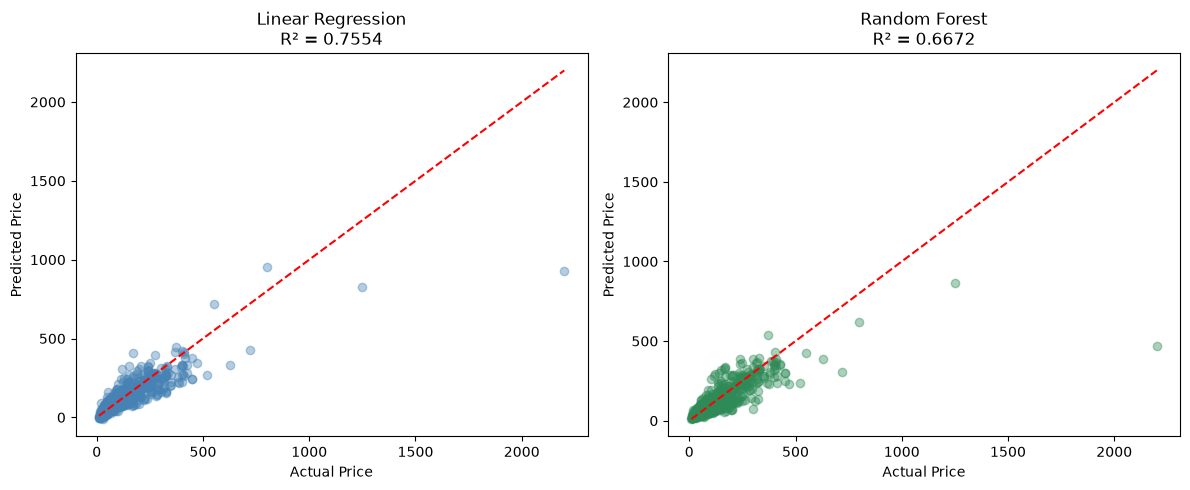

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.4, color="steelblue")
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--")
axes[0].set_title(f"Linear Regression\nR² = {lr_score:.4f}")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.4, color="seagreen")
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], "r--")
axes[1].set_title(f"Random Forest\nR² = {rf_score:.4f}")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")

plt.tight_layout()
plt.savefig("../models/model_comparison.png", dpi=100)
plt.show()

## Model Comparison & Reasoning

### Linear Regression
- **Test R²:** 0.7554
- **Strength:** simple, fast, interpretable. Handles the 244 one-hot encoded
  location columns as a weighted sum — the exact structure one-hot encoding
  is designed for.
- **Why it performs well here:** after per-location outlier removal, the
  relationship between features and price is close to linear. LR exploits
  that directly.

### Random Forest
- **Test R²:** 0.6672
- **Why it underperforms here:** Random Forest splits on one feature at a
  time. With 244 sparse one-hot location columns (243 of them `0` for any
  given house), the trees cannot combine location information efficiently
  and end up memorising the training set.
- Hyperparameter tuning was attempted (RandomizedSearchCV, 20 configurations)
  and did not improve test performance — confirming the problem is the
  encoding, not the hyperparameters.
- Tree-based models would likely win if location were target-encoded into a
  single numeric column instead of one-hot encoded.

### Verdict
**Linear Regression wins on this dataset** because the feature representation
suits linear models. This is not a weakness of Random Forest — it's a mismatch
between the encoding and the model. With target encoding or richer features,
Random Forest would be expected to close the gap.

In [11]:
diff = (rf_score - lr_score) * 100
sign = "+" if diff >= 0 else ""

print("=" * 55)
print("FINAL MODEL SELECTION")
print("=" * 55)
print(f"Winner                : {best_name}")
print(f"Test R²               : {best_score:.4f}")
print(f"Variance explained    : {best_score * 100:.2f}%")
print("Saved to              : models/bengaluru_house_price_model.pkl")
print("-" * 55)
print(f"Linear Regression R²  : {lr_score:.4f}")
print(f"Random Forest R²      : {rf_score:.4f}")
print(f"Difference (RF - LR)  : {sign}{diff:.2f}%")
print("=" * 55)

FINAL MODEL SELECTION
Winner                : Linear Regression
Test R²               : 0.7554
Variance explained    : 75.54%
Saved to              : models/bengaluru_house_price_model.pkl
-------------------------------------------------------
Linear Regression R²  : 0.7554
Random Forest R²      : 0.6672
Difference (RF - LR)  : -8.82%


In [12]:
comparison.to_csv("../models/model_comparison.csv", index=False)
print("Saved model_comparison.csv")

Saved model_comparison.csv
